In [2]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub

/kaggle/input/datasets/ummehabibamoushi/phising-url-detection-dataset/Dataset.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency

sns.set_theme()
RANDOM_STATE = 42

In [4]:
import os
import pandas as pd

folder = "/kaggle/input/datasets/ummehabibamoushi/phising-url-detection-dataset"

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)
            print("Loading:", file_path)
            df = pd.read_csv(file_path)
            break

df.head()

Loading: /kaggle/input/datasets/ummehabibamoushi/phising-url-detection-dataset/Dataset.csv


,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,24,rmit.edu.au,11,0,edu.au,6,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,26,latrobe.edu.au,14,0,edu.au,6,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,23,cqu.edu.au,10,0,edu.au,6,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,19,bond.edu.au,11,0,edu.au,6,0,13,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,22,csu.edu.au,10,0,edu.au,6,1,15,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116600 entries, 0 to 116599
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   url           116600 non-null  object 
 1   url_len       116600 non-null  int64  
 2   dom           116600 non-null  object 
 3   dom_len       116600 non-null  int64  
 4   is_ip         116600 non-null  int64  
 5   tld           116586 non-null  object 
 6   tld_len       116600 non-null  int64  
 7   subdom_cnt    116600 non-null  int64  
 8   letter_cnt    116600 non-null  int64  
 9   digit_cnt     116600 non-null  int64  
 10  special_cnt   116600 non-null  int64  
 11  eq_cnt        116600 non-null  int64  
 12  qm_cnt        116600 non-null  int64  
 13  amp_cnt       116600 non-null  int64  
 14  dot_cnt       116600 non-null  int64  
 15  dash_cnt      116600 non-null  int64  
 16  under_cnt     116600 non-null  int64  
 17  letter_ratio  116600 non-null  float64
 18  digi

In [6]:
df.isnull().sum()

url              0
url_len          0
dom              0
dom_len          0
is_ip            0
tld             14
tld_len          0
subdom_cnt       0
letter_cnt       0
digit_cnt        0
special_cnt      0
eq_cnt           0
qm_cnt           0
amp_cnt          0
dot_cnt          0
dash_cnt         0
under_cnt        0
letter_ratio     0
digit_ratio      0
spec_ratio       0
is_https         0
slash_cnt        0
entropy          0
path_len         0
query_len        0
label            0
dtype: int64

In [7]:
mode_value = df['tld'].mode()[0]
df['tld'] = df['tld'].fillna(mode_value)
print("Filled 'tld' missing values with mode:", mode_value)

Filled 'tld' missing values with mode: com


In [8]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows. Remaining: {len(df)}")

Dropped 1369 duplicate rows. Remaining: 115231


In [9]:
df.isnull().sum()

url             0
url_len         0
dom             0
dom_len         0
is_ip           0
tld             0
tld_len         0
subdom_cnt      0
letter_cnt      0
digit_cnt       0
special_cnt     0
eq_cnt          0
qm_cnt          0
amp_cnt         0
dot_cnt         0
dash_cnt        0
under_cnt       0
letter_ratio    0
digit_ratio     0
spec_ratio      0
is_https        0
slash_cnt       0
entropy         0
path_len        0
query_len       0
label           0
dtype: int64

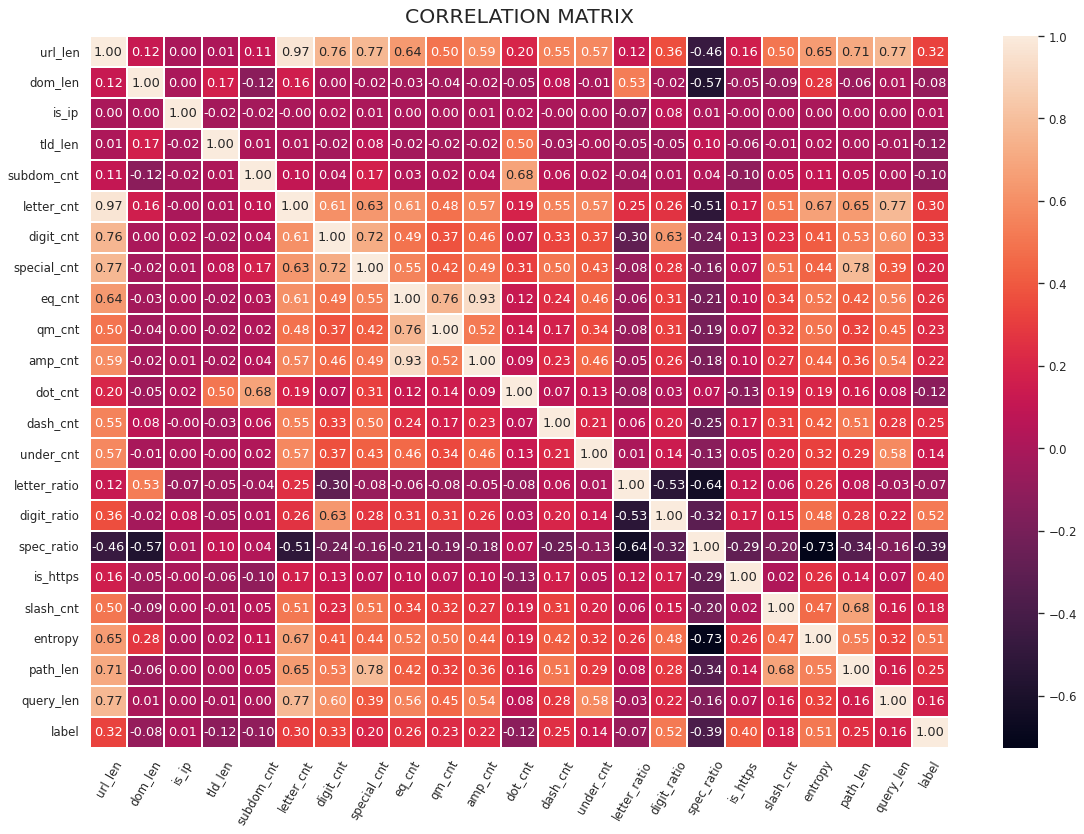

In [10]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation = numeric_df.corr()

plt.figure(figsize=(18, 12), dpi=77)
sns.heatmap(correlation, linecolor='white', linewidths=0.1, annot=True, fmt=".2f")
plt.title('CORRELATION MATRIX', size=19, pad=13)
plt.xticks(rotation=60)
plt.show()

/tmp/ipykernel_49/3891613481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


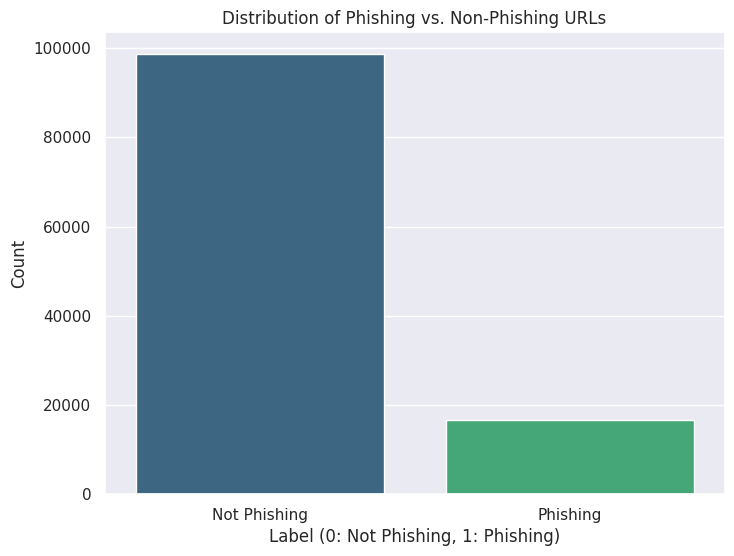

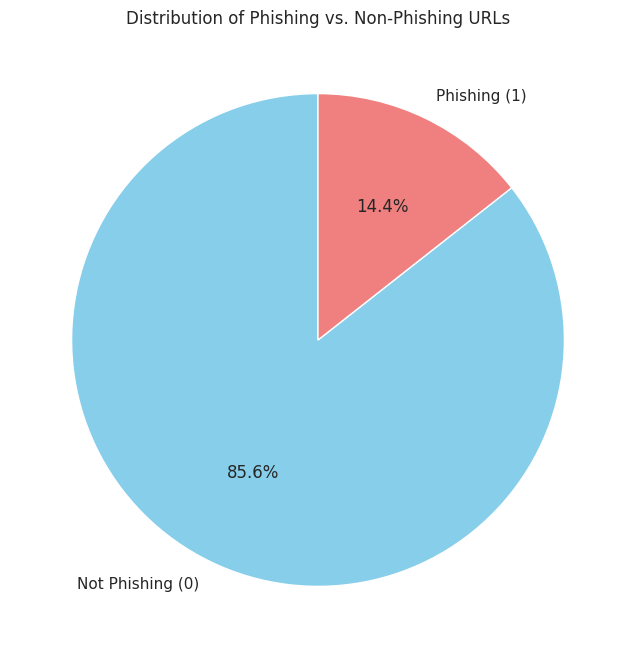

label
0    98641
1    16590
Name: count, dtype: int64
Class imbalance ratio: 5.95 : 1


In [11]:
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Phishing vs. Non-Phishing URLs')
plt.xlabel('Label (0: Not Phishing, 1: Phishing)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Phishing', 'Phishing'])
plt.show()

label_counts = df['label'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=['Not Phishing (0)', 'Phishing (1)'], autopct='%1.1f%%',
        startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Phishing vs. Non-Phishing URLs')
plt.ylabel('')
plt.show()
print(label_counts)
print("Class imbalance ratio:", round(label_counts[0] / label_counts[1], 2), ": 1")

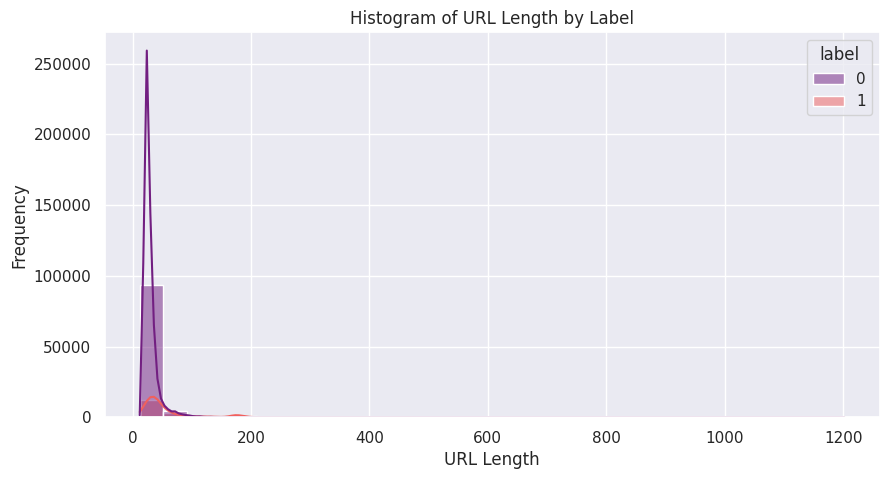

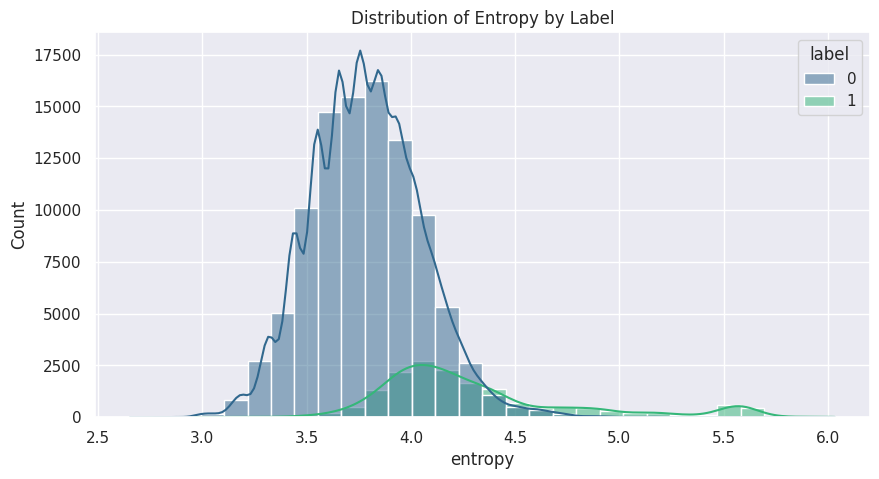

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='url_len', hue='label', kde=True, bins=30, palette='magma')
plt.title('Histogram of URL Length by Label')
plt.xlabel('URL Length')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='entropy', hue='label', kde=True, bins=30, palette='viridis')
plt.title('Distribution of Entropy by Label')
plt.show()

/tmp/ipykernel_49/274927014.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_corr.values, y=label_corr.index, palette='coolwarm')


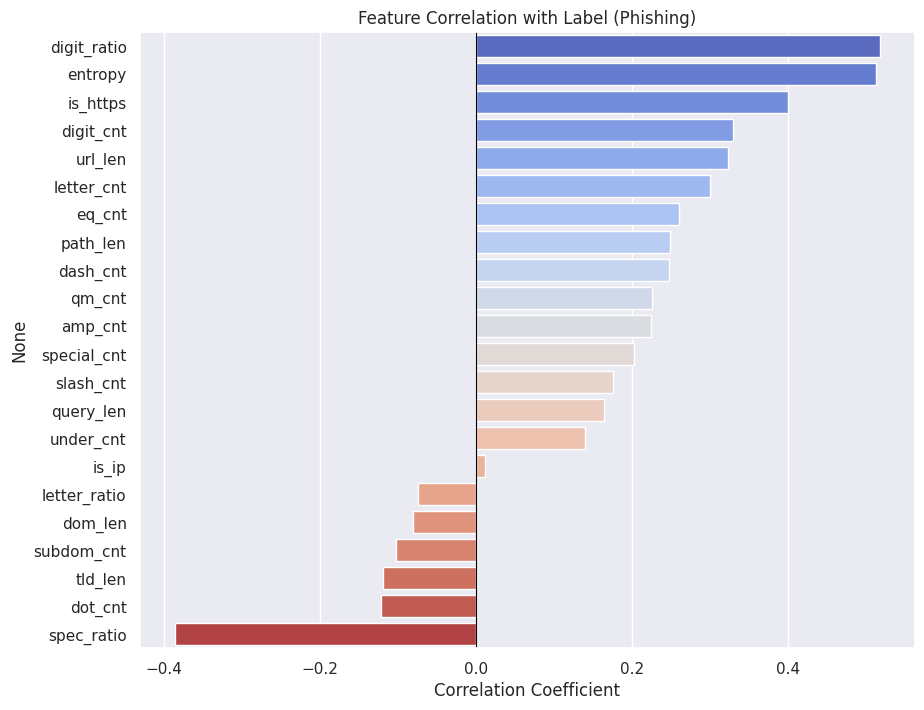

digit_ratio     0.517661
entropy         0.513368
is_https        0.400466
digit_cnt       0.329212
url_len         0.323547
letter_cnt      0.300636
eq_cnt          0.261119
path_len        0.249139
dash_cnt        0.247773
qm_cnt          0.225656
amp_cnt         0.224631
special_cnt     0.203040
slash_cnt       0.176397
query_len       0.164323
under_cnt       0.139964
is_ip           0.011936
letter_ratio   -0.074389
dom_len        -0.080423
subdom_cnt     -0.101656
tld_len        -0.118374
dot_cnt        -0.121231
spec_ratio     -0.385275
Name: label, dtype: float64


In [13]:
label_corr = numeric_df.corr()['label'].drop('label').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=label_corr.values, y=label_corr.index, palette='coolwarm')
plt.title('Feature Correlation with Label (Phishing)')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

print(label_corr)

/tmp/ipykernel_49/3495765817.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not IP', 'Is IP'])
/tmp/ipykernel_49/3495765817.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No HTTPS', 'HTTPS'])


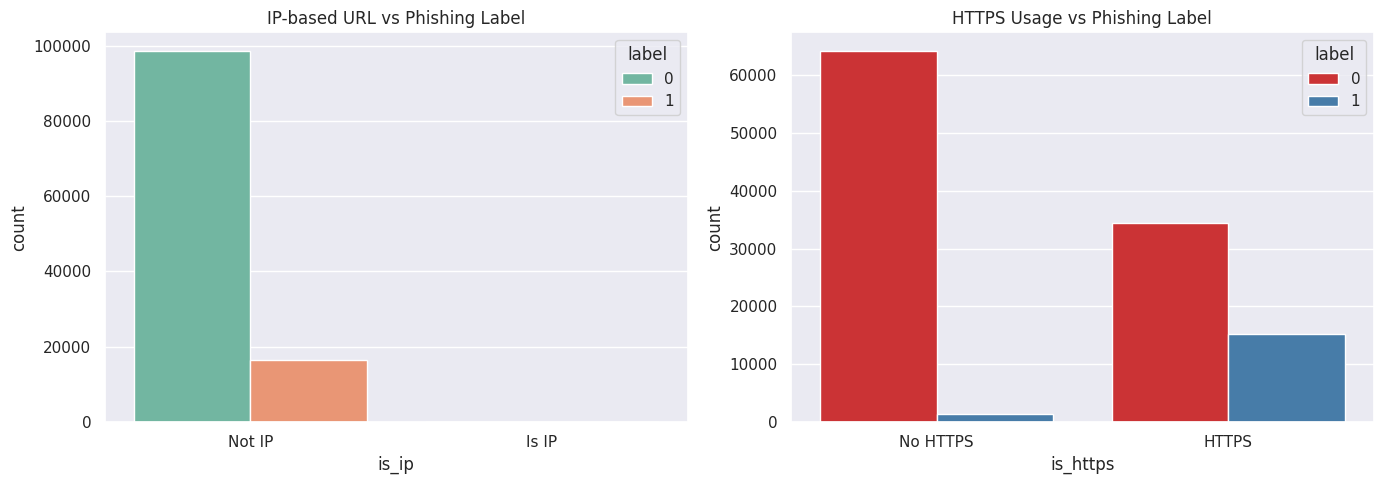

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='is_ip', hue='label', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('IP-based URL vs Phishing Label')
axes[0].set_xticklabels(['Not IP', 'Is IP'])

sns.countplot(x='is_https', hue='label', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('HTTPS Usage vs Phishing Label')
axes[1].set_xticklabels(['No HTTPS', 'HTTPS'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_49/924240963.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='dom_len', data=df, palette='Set2')


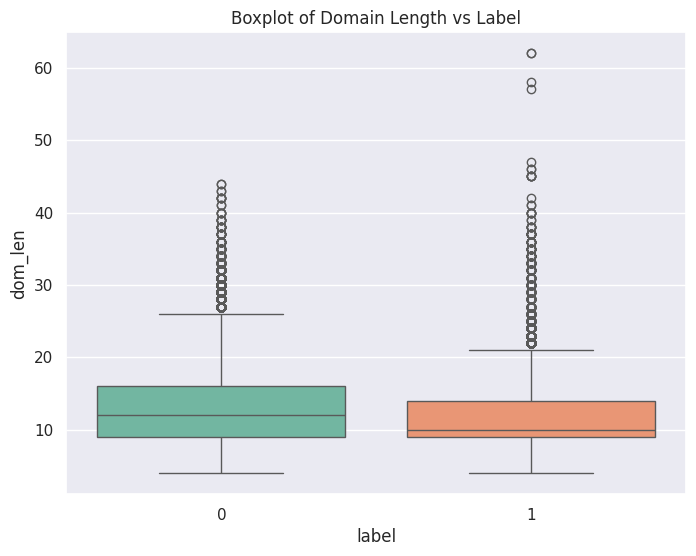

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='dom_len', data=df, palette='Set2')
plt.title('Boxplot of Domain Length vs Label')
plt.show()

               Skewness     Kurtosis
is_ip         94.133702  8859.307652
query_len     37.065017  1795.419449
special_cnt   28.449043  1442.571634
digit_cnt     22.296094   765.299864
under_cnt     19.222774   539.141698
letter_cnt    16.008118   523.832136
amp_cnt       15.656333   487.221743
url_len       15.090273   426.858366
path_len      11.654052   313.277540
eq_cnt        10.484620   218.068728
qm_cnt         9.766930   464.258871
dash_cnt       5.881597    58.864178
digit_ratio    5.145412    32.810500
slash_cnt      3.157022    29.258293
tld_len        2.051055     8.852141
entropy        1.575287     5.307153
dom_len        1.114030     1.537250
dot_cnt        0.972527     4.313170
is_https       0.279726    -1.921787
subdom_cnt    -0.112768     2.846159
spec_ratio    -0.175158    -0.489594
letter_ratio  -1.029200     4.369413


/tmp/ipykernel_49/3085850932.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skew_kurt['Skewness'], y=skew_kurt.index, palette='rocket')


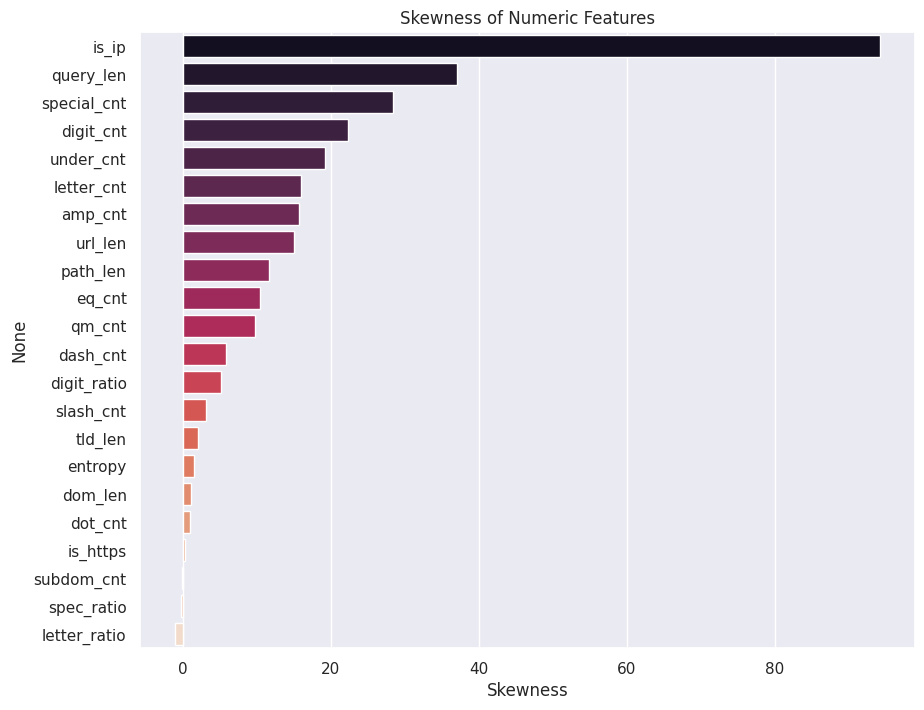

In [16]:
feature_cols_numeric = numeric_df.columns.drop('label')

skew_kurt = pd.DataFrame({
    'Skewness': df[feature_cols_numeric].skew(),
    'Kurtosis': df[feature_cols_numeric].kurt()
}).sort_values('Skewness', ascending=False)

print(skew_kurt)

plt.figure(figsize=(10, 8))
sns.barplot(x=skew_kurt['Skewness'], y=skew_kurt.index, palette='rocket')
plt.title('Skewness of Numeric Features')
plt.show()

/tmp/ipykernel_49/2746462476.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tlds.values, y=top_tlds.index, palette='crest')


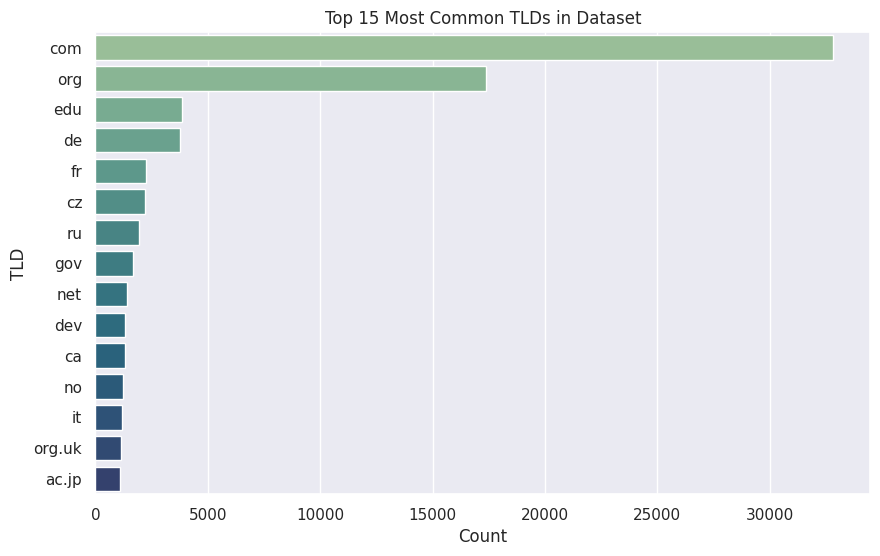

TLD-wise Phishing Rate (Top 10):
tld
od.ua     1.0
golf      1.0
beauty    1.0
goog      1.0
link      1.0
now       1.0
bar       1.0
zone      1.0
nf        1.0
autos     1.0
Name: label, dtype: float64


In [17]:
top_tlds = df['tld'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_tlds.values, y=top_tlds.index, palette='crest')
plt.title('Top 15 Most Common TLDs in Dataset')
plt.xlabel('Count')
plt.ylabel('TLD')
plt.show()

tld_phishing_rate = df.groupby('tld')['label'].mean().sort_values(ascending=False).head(10)
print("TLD-wise Phishing Rate (Top 10):")
print(tld_phishing_rate)

              Not Phishing (0)  Phishing (1)
url_len              29.103365     56.311875
dom_len              13.023540     11.844002
is_ip                 0.000061      0.000422
tld_len               3.391034      2.911272
subdom_cnt            0.864752      0.725136
letter_cnt           22.282256     41.557987
digit_cnt             0.146805      5.756480
special_cnt           6.674304      8.997408
eq_cnt                0.027250      0.395600
qm_cnt                0.020083      0.149066
amp_cnt               0.007989      0.239602
dot_cnt               2.187295      1.927245
dash_cnt              0.244300      0.937432
under_cnt             0.026216      0.220072
letter_ratio          0.754307      0.741760
digit_ratio           0.003079      0.073798
spec_ratio            0.242614      0.184443
is_https              0.349419      0.914286
slash_cnt             3.148437      3.617661
entropy               3.788811      4.316303
path_len              4.621273     17.163110
query_len 

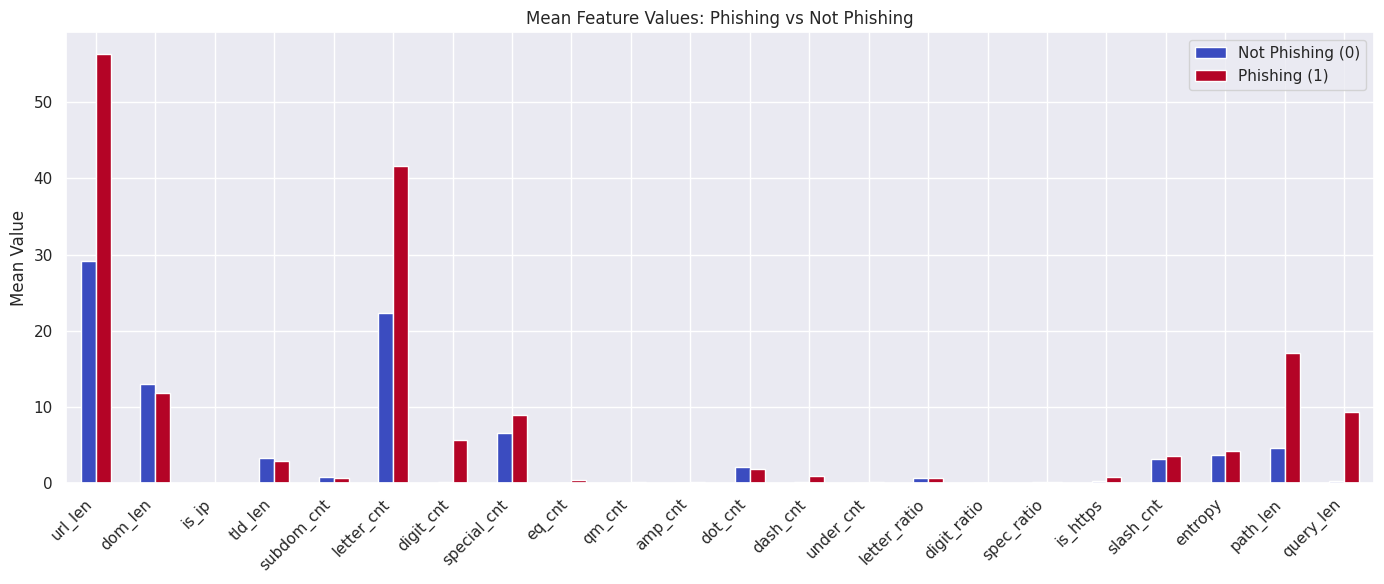

In [18]:
summary_comparison = df.groupby('label')[feature_cols_numeric].mean().T
summary_comparison.columns = ['Not Phishing (0)', 'Phishing (1)']
print(summary_comparison)

summary_comparison.plot(kind='bar', figsize=(14, 6), colormap='coolwarm')
plt.title('Mean Feature Values: Phishing vs Not Phishing')
plt.ylabel('Mean Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

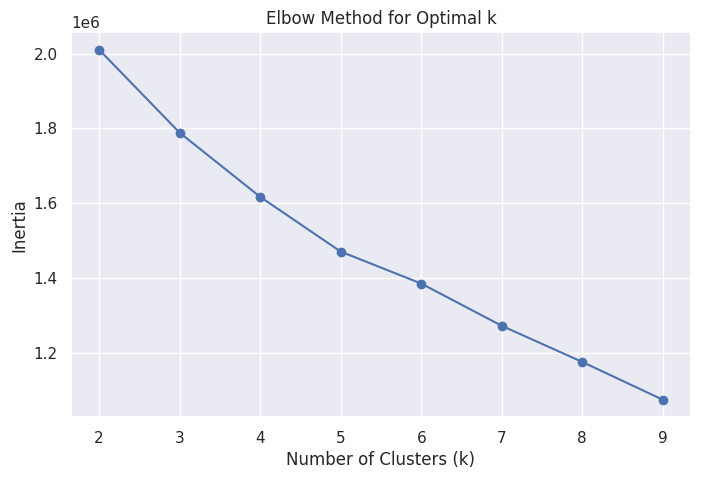

In [20]:
X_cluster = df[feature_cols_numeric]

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

inertia = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Silhouette Score: 0.7536530410826132
Counts:
 label      0      1
row_0              
0        309   1939
1      98332  14651

Row-wise Percentage:
 label          0          1
row_0                      
0      13.745552  86.254448
1      87.032562  12.967438

Chi-square statistic: 9599.75
P-value: 0.0
Cluster and Label are statistically significantly associated (confirms clusters roughly track phishing/not-phishing — this is exactly why 'cluster' must NOT be used as a model feature: it would leak the label).


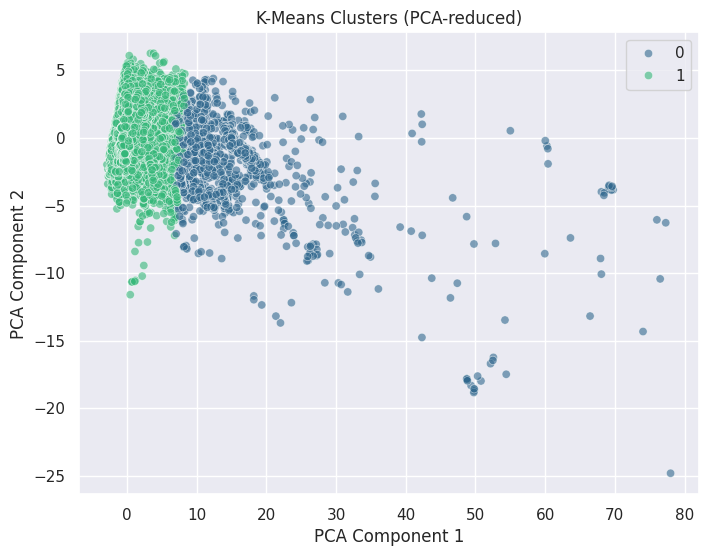

In [21]:
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)   # NOT stored back into df -> won't leak into features

sil_score = silhouette_score(X_cluster_scaled, cluster_labels)
print("Silhouette Score:", sil_score)

crosstab = pd.crosstab(cluster_labels, df['label'])
crosstab_pct = pd.crosstab(cluster_labels, df['label'], normalize='index') * 100
print("Counts:\n", crosstab)
print("\nRow-wise Percentage:\n", crosstab_pct)

chi2, p_value, dof, expected = chi2_contingency(crosstab)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value}")
if p_value < 0.05:
    print("Cluster and Label are statistically significantly associated "
          "(confirms clusters roughly track phishing/not-phishing — this is exactly "
          "why 'cluster' must NOT be used as a model feature: it would leak the label).")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', alpha=0.6)
plt.title('K-Means Clusters (PCA-reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [22]:
from sklearn.model_selection import GroupShuffleSplit

X = df.drop(columns=['label', 'url'])
y = df['label']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=X['dom']))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

dom_overlap_new = set(X_train['dom']) & set(X_test['dom'])
print("New domain overlap:", len(dom_overlap_new))
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

New domain overlap: 0
Train shape: (89251, 24) Test shape: (25980, 24)


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from category_encoders.wrapper import NestedCVWrapper
import category_encoders as ce

categorical_cols = ['dom', 'tld']
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

target_enc_cv = NestedCVWrapper(
    ce.TargetEncoder(smoothing=10),
    cv=5,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', target_enc_cv, categorical_cols),
        ('scale', StandardScaler(), numeric_cols)
    ]
)

Accuracy: 0.8926
Precision: 0.9035
Recall: 0.8926
F1-Score: 0.8813


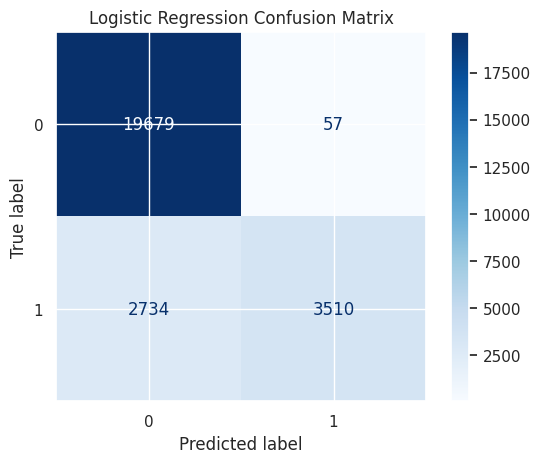

In [24]:
from sklearn.pipeline import Pipeline
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=['0','1']).plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

Accuracy: 0.9624
Precision: 0.9621
Recall: 0.9624
F1-Score: 0.9620

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     19736
           1       0.94      0.90      0.92      6244

    accuracy                           0.96     25980
   macro avg       0.96      0.94      0.95     25980
weighted avg       0.96      0.96      0.96     25980

Train acc: 0.986678020414337
Test acc: 0.9623556581986143


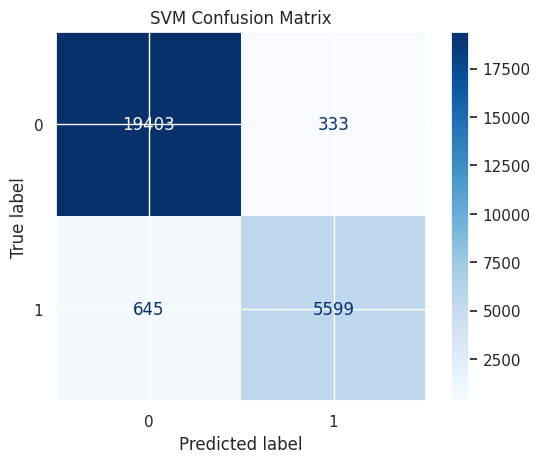

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', SVC(
        kernel='rbf',
        C=1.0,
        class_weight='balanced',
        random_state=42
    ))
])

svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

print(f"Accuracy: {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1-Score: {svm_f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_svm))

print("Train acc:", svm_pipe.score(X_train, y_train))
print("Test acc:", svm_pipe.score(X_test, y_test))

cm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm, display_labels=['0','1']).plot(cmap='Blues', values_format='d')
plt.title('SVM Confusion Matrix')
plt.show()

Accuracy: 0.8993
Precision: 0.8998
Recall: 0.8993
F1-Score: 0.8932


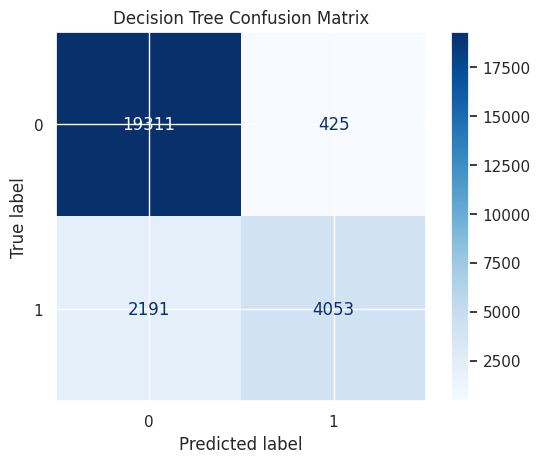

In [26]:
dt_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    ))
])
dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1-Score: {dt_f1:.4f}")

cm = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm, display_labels=['0','1']).plot(cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.show()

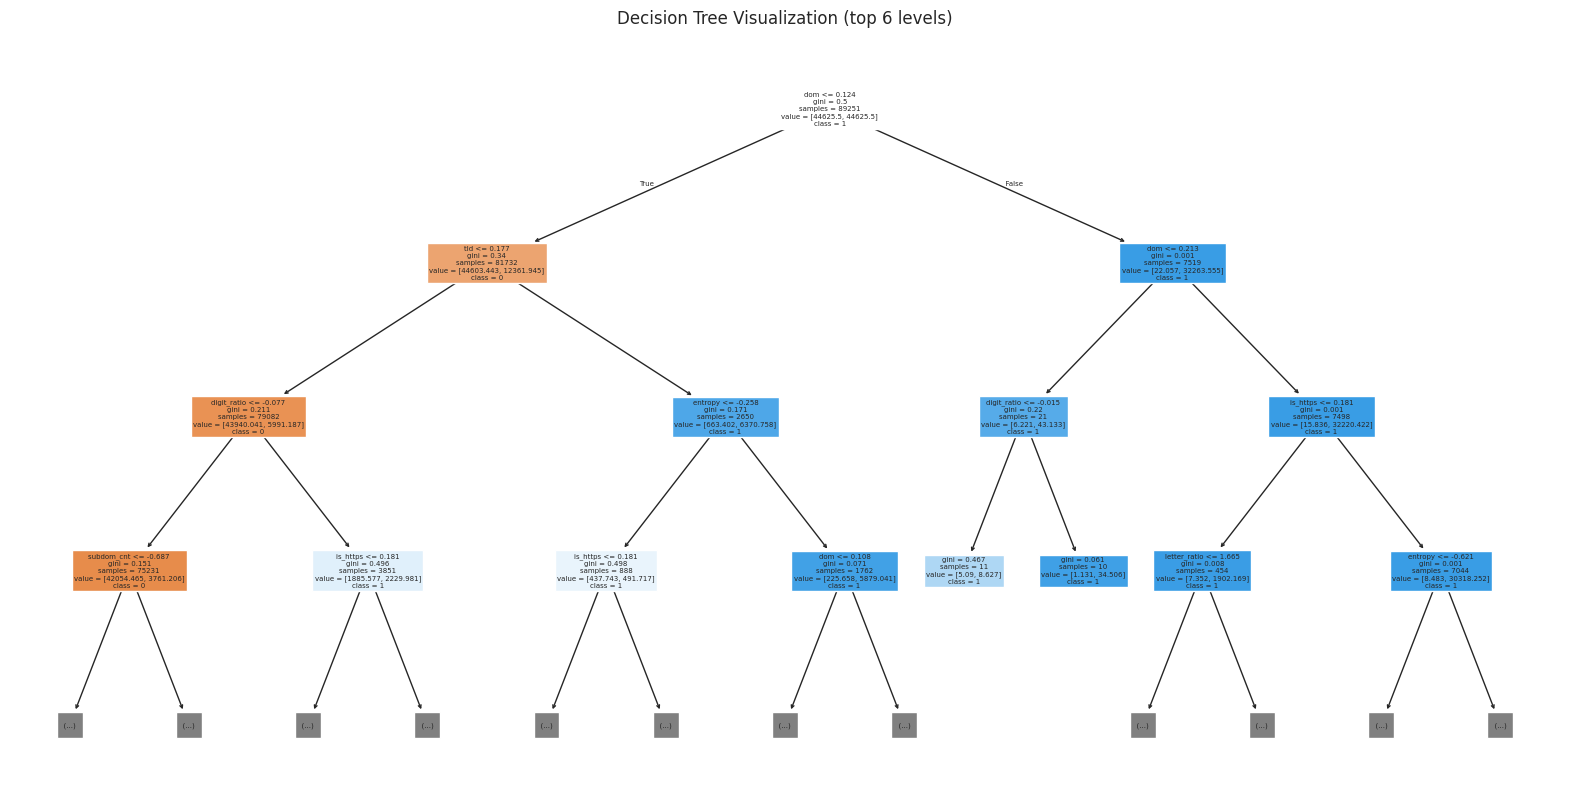

In [27]:
from sklearn import tree

dt_model_fitted = dt_pipe.named_steps['model']

feature_names_out = categorical_cols + numeric_cols

plt.figure(figsize=(20, 10))
tree.plot_tree(
    dt_model_fitted,
    feature_names=feature_names_out,
    class_names=['0', '1'],
    filled=True,
    max_depth=3
)
plt.title('Decision Tree Visualization (top 6 levels)')
plt.show()

Accuracy: 0.8518
Precision: 0.8469
Recall: 0.8518
F1-Score: 0.8389

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     19736
           1       0.81      0.51      0.62      6244

    accuracy                           0.85     25980
   macro avg       0.83      0.73      0.76     25980
weighted avg       0.85      0.85      0.84     25980

Train acc: 0.9459837985008571
Test acc: 0.8517705927636644


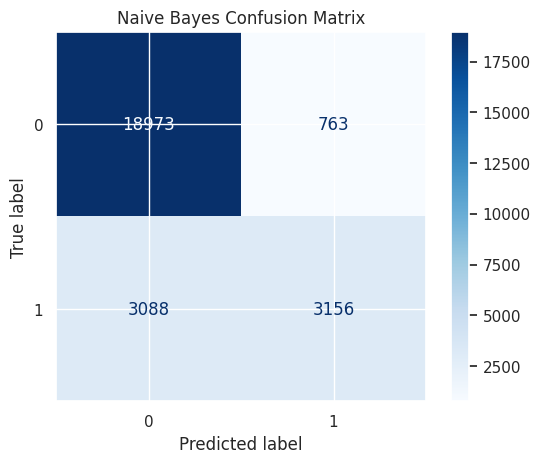

In [28]:
from sklearn.naive_bayes import GaussianNB

nb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', GaussianNB())
])

nb_pipe.fit(X_train, y_train)
y_pred_nb = nb_pipe.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average='weighted')
nb_recall = recall_score(y_test, y_pred_nb, average='weighted')
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')

print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-Score: {nb_f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

# overfitting check
print("Train acc:", nb_pipe.score(X_train, y_train))
print("Test acc:", nb_pipe.score(X_test, y_test))

cm = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm, display_labels=['0','1']).plot(cmap='Blues', values_format='d')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

Accuracy: 0.9265
Precision: 0.9267
Recall: 0.9265
F1-Score: 0.9237

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     19736
           1       0.93      0.75      0.83      6244

    accuracy                           0.93     25980
   macro avg       0.93      0.87      0.89     25980
weighted avg       0.93      0.93      0.92     25980

Train acc: 0.9976246764742132
Test acc: 0.9265204003079291


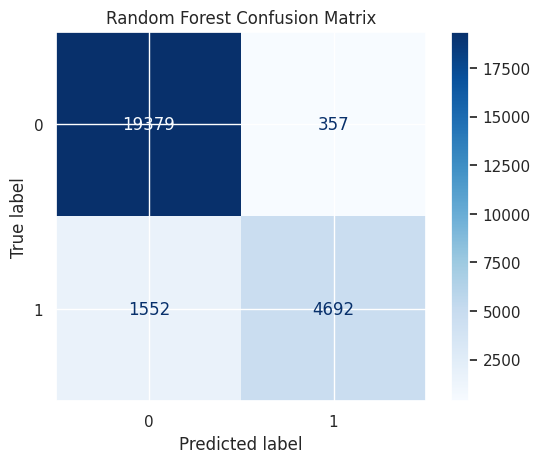

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', rf_model)
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

# Evaluation Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# overfitting check
print("Train acc:", rf_pipe.score(X_train, y_train))
print("Test acc:", rf_pipe.score(X_test, y_test))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=['0','1']).plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

Accuracy: 0.9154
Precision: 0.9202
Recall: 0.9154
F1-Score: 0.9097


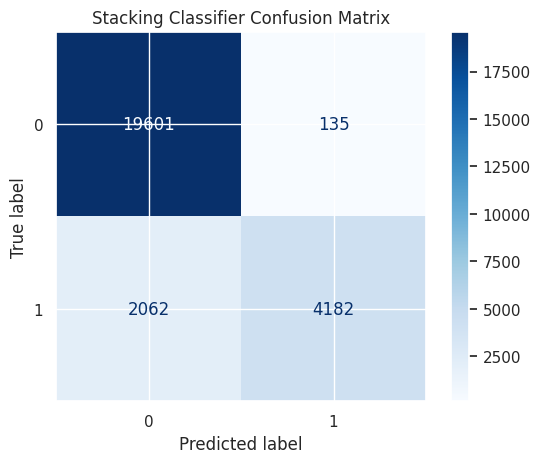

In [30]:
lr_base = LogisticRegression(C=0.1, max_iter=1000, random_state=42)

dt_base = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

stack_model = StackingClassifier(
    estimators=[('lr', lr_base), ('dt', dt_base), ('rf', rf_base)],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', stack_model)
])

stack_pipe.fit(X_train, y_train)
y_pred_stack = stack_pipe.predict(X_test)

stack_accuracy = accuracy_score(y_test, y_pred_stack)
stack_precision = precision_score(y_test, y_pred_stack, average='weighted')
stack_recall = recall_score(y_test, y_pred_stack, average='weighted')
stack_f1 = f1_score(y_test, y_pred_stack, average='weighted')

print(f"Accuracy: {stack_accuracy:.4f}")
print(f"Precision: {stack_precision:.4f}")
print(f"Recall: {stack_recall:.4f}")
print(f"F1-Score: {stack_f1:.4f}")

cm = confusion_matrix(y_test, y_pred_stack)
ConfusionMatrixDisplay(cm, display_labels=['0','1']).plot(cmap='Blues', values_format='d')
plt.title('Stacking Classifier Confusion Matrix')
plt.show()

In [31]:
train_acc = stack_pipe.score(X_train, y_train)
test_acc = stack_pipe.score(X_test, y_test)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9993165342685236
Test Accuracy: 0.9154349499615089


In [32]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Naive Bayes", "SVM", "Stacking"],
    "Accuracy":  [accuracy, dt_accuracy, rf_accuracy, nb_accuracy, svm_accuracy, stack_accuracy],
    "Precision": [precision, dt_precision, rf_precision, nb_precision, svm_precision, stack_precision],
    "Recall":    [recall, dt_recall, rf_recall, nb_recall, svm_recall, stack_recall],
    "F1-Score":  [f1, dt_f1, rf_f1, nb_f1, svm_f1, stack_f1],
}).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

results = results.round(4)
results

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.9624,0.9621,0.9624,0.9620
1,Random Forest,0.9265,0.9267,0.9265,0.9237
2,Stacking,0.9154,0.9202,0.9154,0.9097
3,Decision Tree,0.8993,0.8998,0.8993,0.8932
4,Logistic Regression,0.8926,0.9035,0.8926,0.8813
5,Naive Bayes,0.8518,0.8469,0.8518,0.8389


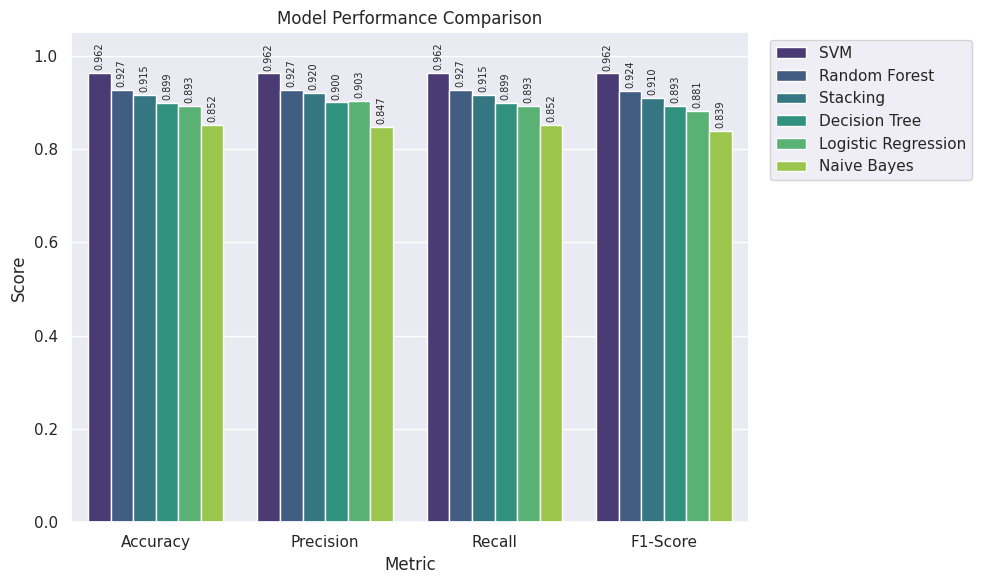

In [33]:
# ==== results DataFrame-এ SVM যোগ করা ====
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Naive Bayes", "SVM", "Stacking"],
    "Accuracy":  [accuracy, dt_accuracy, rf_accuracy, nb_accuracy, svm_accuracy, stack_accuracy],
    "Precision": [precision, dt_precision, rf_precision, nb_precision, svm_precision, stack_precision],
    "Recall":    [recall, dt_recall, rf_recall, nb_recall, svm_recall, stack_recall],
    "F1-Score":  [f1, dt_f1, rf_f1, nb_f1, svm_f1, stack_f1],
}).sort_values(by="Accuracy", ascending=False)
results


# ==== তোমার প্লট কোড (অপরিবর্তিত) ====
plt.figure(figsize=(10, 6))
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')
ax = sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model', palette='viridis')
plt.ylim(0, 1.05)
plt.title('Model Performance Comparison')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, rotation=90, padding=2)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Reviewer-requested experiments (camera-ready additions)
Everything below reuses the cleaned `df` from the cells above (dedup + tld imputation) and **does not change any earlier cell**.
Run order: all earlier cells first, then these top to bottom. Results are written to `results/`.

| Section | Reviewer point |
|---|---|
| E0 data audit | R7.2, R8.1 |
| E1 controlled split-only comparison | R7.1, R8.3 |
| E2 feature ablations | R3, R7.3, R7.4, R7.5 |
| E4 model selection on TRAIN only | R8.2 |
| E6 final test metrics, confusion matrices, bootstrap CI | R3, R7.7 |
| E3 repeated grouped splits + Wilcoxon | R3 |
| E5 K-Means with Cramér's V | R7.6 |

In [34]:
# ---- config ----
import os, json, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (average_precision_score, balanced_accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, matthews_corrcoef, precision_score,
                             recall_score, roc_auc_score, adjusted_rand_score, normalized_mutual_info_score)
from sklearn.svm import SVC
warnings.filterwarnings("ignore")

SEED = 42
QUICK = False            
REPEATS = 5             
MODELS = ["LR", "DT", "NB", "RF", "Stacking", "SVM"]
SELECT_METRIC = "phish_f1"   # 'phish_f1' | 'phish_rec' | 'pr_auc'
OUT = "results"; os.makedirs(OUT, exist_ok=True)
CAT_COLS = ["dom", "tld"]
PATH_FEATS = ["path_len", "query_len", "eq_cnt", "qm_cnt", "amp_cnt", "slash_cnt"]

In [35]:
# ---- helpers: grouped nested target encoder, models, metrics ----
class NestedTargetEncoder(BaseEstimator, TransformerMixin):
    """Out-of-fold smoothed target encoding.
    fit_transform: each training row is encoded by an encoder fitted on the OTHER inner folds.
    transform: encoder fitted on the full training set; unseen categories -> global prior.
    grouped=True  : inner folds are GroupKFold on `group_col` (domain never straddles inner folds)
    grouped=False : stratified row-wise KFold (what NestedCVWrapper(cv=5) does)"""
    def __init__(self, cat_cols, group_col="grp", n_splits=5, smoothing=10, grouped=True, seed=SEED):
        self.cat_cols, self.group_col = cat_cols, group_col
        self.n_splits, self.smoothing, self.grouped, self.seed = n_splits, smoothing, grouped, seed
    def _enc(self): return ce.TargetEncoder(cols=self.cat_cols, smoothing=self.smoothing)
    def fit(self, X, y):
        self.enc_ = self._enc().fit(X[self.cat_cols], y); return self
    def fit_transform(self, X, y):
        X = X.reset_index(drop=True); y = pd.Series(np.asarray(y)).reset_index(drop=True)
        out = np.zeros((len(X), len(self.cat_cols)))
        splits = (GroupKFold(self.n_splits).split(X, y, groups=X[self.group_col]) if self.grouped
                  else StratifiedKFold(self.n_splits, shuffle=True, random_state=self.seed).split(X, y))
        for a_tr, a_va in splits:
            enc = self._enc().fit(X.loc[a_tr, self.cat_cols], y.loc[a_tr])
            out[a_va] = enc.transform(X.loc[a_va, self.cat_cols]).to_numpy()
        self.fit(X, y); return out
    def transform(self, X): return self.enc_.transform(X[self.cat_cols]).to_numpy()

def make_model(name, seed=SEED):
    if name == "LR":  return LogisticRegression(max_iter=1000, random_state=seed)
    if name == "DT":  return DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, class_weight="balanced", random_state=seed)
    if name == "NB":  return GaussianNB()
    if name == "RF":  return RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=20, min_samples_leaf=10,
                                                    class_weight="balanced", random_state=seed, n_jobs=-1)
    if name == "Stacking":   # identical to the stacking cell above
        return StackingClassifier(
            estimators=[("lr", LogisticRegression(C=0.1, max_iter=1000, random_state=seed)),
                        ("dt", DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, class_weight="balanced", random_state=seed)),
                        ("rf", RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=10,
                                                      class_weight="balanced", random_state=seed, n_jobs=-1))],
            final_estimator=LogisticRegression(), n_jobs=-1)
    if name == "SVM": return SVC(kernel="rbf", C=1.0, class_weight="balanced", random_state=seed)
    raise ValueError(name)

def build_pipe(model_name, num_cols, cat_cols, grouped_te, seed=SEED):
    tf = []
    if cat_cols: tf.append(("te", NestedTargetEncoder(cat_cols, grouped=grouped_te, seed=seed), cat_cols + ["grp"]))
    tf.append(("sc", StandardScaler(), num_cols))
    return Pipeline([("prep", ColumnTransformer(tf)), ("model", make_model(model_name, seed))])

def scores_of(pipe, Xd):
    m = pipe.named_steps["model"]; Z = pipe.named_steps["prep"].transform(Xd)
    return m.predict_proba(Z)[:, 1] if hasattr(m, "predict_proba") else m.decision_function(Z)

def metrics(yt, pred, score=None):
    tn, fp, fn, tp = confusion_matrix(yt, pred, labels=[0, 1]).ravel()
    d = dict(acc=(tp+tn)/len(yt), w_prec=precision_score(yt, pred, average="weighted", zero_division=0),
             w_rec=recall_score(yt, pred, average="weighted"), w_f1=f1_score(yt, pred, average="weighted"),
             phish_prec=precision_score(yt, pred, zero_division=0), phish_rec=recall_score(yt, pred),
             phish_f1=f1_score(yt, pred), bal_acc=balanced_accuracy_score(yt, pred), mcc=matthews_corrcoef(yt, pred),
             TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn), test_prev=float(np.mean(yt)))
    if score is not None: d["roc_auc"] = roc_auc_score(yt, score); d["pr_auc"] = average_precision_score(yt, score)
    return d

def group_split(Xd, yd, seed, test_size=0.2):
    return next(GroupShuffleSplit(1, test_size=test_size, random_state=seed).split(Xd, yd, groups=Xd["grp"]))
def row_split(Xd, yd, seed, test_size=0.2):
    return next(StratifiedShuffleSplit(1, test_size=test_size, random_state=seed).split(Xd, yd))

def fit_eval(model, tr, te, num_cols, cat_cols, grouped_te, Xd, yd, seed=SEED):
    pipe = build_pipe(model, num_cols, cat_cols, grouped_te, seed)
    pipe.fit(Xd.iloc[tr], yd.iloc[tr])
    pred = pipe.predict(Xd.iloc[te]); sc = scores_of(pipe, Xd.iloc[te])
    return pipe, pred, sc, metrics(yd.iloc[te], pred, sc)

def cluster_bootstrap(yt, pred, groups, n_boot=1000, seed=SEED):
    """95% CI by resampling whole domains."""
    d = pd.DataFrame({"g": groups, "y": np.asarray(yt), "p": np.asarray(pred)})
    d["tp"] = (d.y == 1) & (d.p == 1); d["fn"] = (d.y == 1) & (d.p == 0)
    d["fp"] = (d.y == 0) & (d.p == 1); d["tn"] = (d.y == 0) & (d.p == 0)
    agg = d.groupby("g")[["tp", "fn", "fp", "tn"]].sum().to_numpy(); rng = np.random.default_rng(seed); out = []
    for _ in range(n_boot):
        tp, fn, fp, tn = agg[rng.integers(0, len(agg), len(agg))].sum(0)
        rec = tp/max(tp+fn, 1); prec = tp/max(tp+fp, 1); tnr = tn/max(tn+fp, 1)
        out.append((rec, prec, 2*prec*rec/max(prec+rec, 1e-12), (rec+tnr)/2))
    q = np.percentile(np.array(out), [2.5, 97.5], axis=0)
    return {k: (round(q[0, i], 4), round(q[1, i], 4)) for i, k in enumerate(["phish_rec", "phish_prec", "phish_f1", "bal_acc"])}

def cramers_v(table, correction=False):
    chi2 = chi2_contingency(table, correction=correction)[0]
    n = np.asarray(table).sum(); k = min(np.asarray(table).shape) - 1
    return chi2, float(np.sqrt(chi2/(n*k)))

def feature_sets(all_num):
    return {"full (22 num + dom + tld)": (all_num, CAT_COLS),
            "no dom": (all_num, ["tld"]),
            "no dom, no tld (lexical only)": (all_num, []),
            "no path/query features": ([c for c in all_num if c not in PATH_FEATS], CAT_COLS),
            "no is_https": ([c for c in all_num if c != "is_https"], CAT_COLS)}

In [36]:
# ---- data for the new experiments (uses the cleaned `df` from above) ----
dfx = df.copy()
if QUICK: dfx = dfx.sample(min(12000, len(dfx)), random_state=SEED).reset_index(drop=True); REPEATS = 2
yx = dfx["label"].astype(int)
ALL_NUM = [c for c in dfx.columns if c not in ("url", "dom", "tld", "label")]
Xx = dfx[ALL_NUM + CAT_COLS].copy(); Xx["grp"] = dfx["dom"]    # grp = domain, used ONLY for splitting / inner folds
print("rows:", len(dfx), "| phishing:", int(yx.sum()), "| numeric features:", len(ALL_NUM))
tr, te = group_split(Xx, yx, SEED)                              # headline split (same as the cells above)
print("train/test:", len(tr), len(te))

rows: 115231 | phishing: 16590 | numeric features: 22
train/test: 89251 25980


## E0. Data audit (R7.2, R8.1)

In [37]:
audit = {"train_rows": len(tr), "test_rows": len(te),
         "train_prev": float(yx.iloc[tr].mean()), "test_prev": float(yx.iloc[te].mean()), "overall_prev": float(yx.mean()),
         "dom_overlap_grouped": len(set(Xx.iloc[tr].dom) & set(Xx.iloc[te].dom)), "unique_dom": int(dfx.dom.nunique())}
rtr, rte = row_split(Xx, yx, SEED)
audit["rowwise_test_prev"] = float(yx.iloc[rte].mean())
audit["rowwise_test_rows_with_seen_dom"] = float(Xx.iloc[rte].dom.isin(set(Xx.iloc[rtr].dom)).mean())
try:   # is `dom` a registrable domain or a hostname?  (pip install tldextract)
    import tldextract
    ext = tldextract.TLDExtract(suffix_list_urls=())
    reg = dfx["dom"].map(lambda h: ext(h).registered_domain or h)
    audit["dom_values_not_registrable"] = int((reg != dfx["dom"]).sum())
    audit["registrable_overlap_after_dom_split"] = len(set(reg.iloc[tr]) & set(reg.iloc[te]))
except Exception as e:
    audit["tldextract"] = f"skipped ({e})"
audit["is_https_rate_by_class"] = {int(k): float(v) for k, v in dfx.groupby("label")["is_https"].mean().items()}
audit["mean_path_len_by_class"] = {int(k): float(v) for k, v in dfx.groupby("label")["path_len"].mean().items()}
json.dump(audit, open(f"{OUT}/E0_audit.json", "w"), indent=2)
print(json.dumps(audit, indent=1))

{
 "train_rows": 89251,
 "test_rows": 25980,
 "train_prev": 0.11592026980089859,
 "test_prev": 0.2403387220939184,
 "overall_prev": 0.14397167428903682,
 "dom_overlap_grouped": 0,
 "unique_dom": 90860,
 "rowwise_test_prev": 0.14396667679090555,
 "rowwise_test_rows_with_seen_dom": 0.23777498155942206,
 "tldextract": "skipped (No module named 'tldextract')",
 "is_https_rate_by_class": {
  "0": 0.3494185987571091,
  "1": 0.9142857142857143
 },
 "mean_path_len_by_class": {
  "0": 4.621273101448688,
  "1": 17.163110307414104
 }
}


## E1. Controlled split-only comparison (R7.1, R8.3)
Same features, same target encoding, same model settings. **A→B changes only the split**; **B→C changes only whether the inner encoding folds are grouped by domain.**

In [38]:
conds = {"A: row-wise split + row-wise inner TE": (row_split, False),
         "B: domain split + row-wise inner TE": (group_split, False),
         "C: domain split + domain-grouped inner TE": (group_split, True)}
rows = []
for m in MODELS:
    for cname, (splitter, gte) in conds.items():
        tr_, te_ = splitter(Xx, yx, SEED)
        _, _, _, mt = fit_eval(m, tr_, te_, ALL_NUM, CAT_COLS, gte, Xx, yx)
        rows.append({"model": m, "condition": cname, **mt}); print("E1", m, cname, round(mt["acc"], 4), round(mt["phish_rec"], 4))
E1 = pd.DataFrame(rows); E1.to_csv(f"{OUT}/E1_controlled_split_comparison.csv", index=False)
E1.pivot(index="model", columns="condition", values="acc").round(4)

E1 LR A: row-wise split + row-wise inner TE 0.9837 0.9096
E1 LR B: domain split + row-wise inner TE 0.8926 0.5621
E1 LR C: domain split + domain-grouped inner TE 0.9435 0.7921
E1 DT A: row-wise split + row-wise inner TE 0.9812 0.9479
E1 DT B: domain split + row-wise inner TE 0.8993 0.6491
E1 DT C: domain split + domain-grouped inner TE 0.9301 0.8477
E1 NB A: row-wise split + row-wise inner TE 0.9422 0.8448
E1 NB B: domain split + row-wise inner TE 0.8518 0.5054
E1 NB C: domain split + domain-grouped inner TE 0.8514 0.5195
E1 RF A: row-wise split + row-wise inner TE 0.9858 0.9638
E1 RF B: domain split + row-wise inner TE 0.9265 0.7514
E1 RF C: domain split + domain-grouped inner TE 0.9473 0.8852
E1 Stacking A: row-wise split + row-wise inner TE 0.9899 0.9551
E1 Stacking B: domain split + row-wise inner TE 0.9154 0.6698
E1 Stacking C: domain split + domain-grouped inner TE 0.946 0.8062
E1 SVM A: row-wise split + row-wise inner TE 0.9844 0.9687
E1 SVM B: domain split + row-wise inner TE 0

condition,A: row-wise split + row-wise inner TE,B: domain split + row-wise inner TE,C: domain split + domain-grouped inner TE
model,,,
DT,0.9812,0.8993,0.9301
LR,0.9837,0.8926,0.9435
NB,0.9422,0.8518,0.8514
RF,0.9858,0.9265,0.9473
SVM,0.9844,0.9624,0.9692
Stacking,0.9899,0.9154,0.9460


In [39]:
E1.pivot(index="model", columns="condition", values="phish_rec").round(4)   # phishing-class recall

condition,A: row-wise split + row-wise inner TE,B: domain split + row-wise inner TE,C: domain split + domain-grouped inner TE
model,,,
DT,0.9479,0.6491,0.8477
LR,0.9096,0.5621,0.7921
NB,0.8448,0.5054,0.5195
RF,0.9638,0.7514,0.8852
SVM,0.9687,0.8967,0.9457
Stacking,0.9551,0.6698,0.8062


In [40]:
E1.pivot(index="model", columns="condition", values="bal_acc").round(4)     # balanced accuracy

condition,A: row-wise split + row-wise inner TE,B: domain split + row-wise inner TE,C: domain split + domain-grouped inner TE
model,,,
DT,0.9673,0.8138,0.9019
LR,0.9529,0.7796,0.8918
NB,0.9017,0.7334,0.7380
RF,0.9766,0.8667,0.9261
SVM,0.9778,0.9399,0.9612
Stacking,0.9754,0.8315,0.8982


## E2. Feature ablations — domain split, grouped inner encoding (R3, R7.3, R7.4, R7.5)

In [41]:
rows = []
for fname, (nc, cc) in feature_sets(ALL_NUM).items():
    for m in MODELS:
        _, _, _, mt = fit_eval(m, tr, te, nc, cc, True, Xx, yx)
        rows.append({"features": fname, "model": m, **mt}); print("E2", fname, m, round(mt["phish_f1"], 4))
E2 = pd.DataFrame(rows); E2.to_csv(f"{OUT}/E2_feature_ablation.csv", index=False)
E2.pivot(index="model", columns="features", values="phish_f1").round(4)

E2 full (22 num + dom + tld) LR 0.8709
E2 full (22 num + dom + tld) DT 0.8535
E2 full (22 num + dom + tld) NB 0.627
E2 full (22 num + dom + tld) RF 0.8899
E2 full (22 num + dom + tld) Stacking 0.8778
E2 full (22 num + dom + tld) SVM 0.9366
E2 no dom LR 0.8713
E2 no dom DT 0.8535
E2 no dom NB 0.6271
E2 no dom RF 0.892
E2 no dom Stacking 0.8772
E2 no dom SVM 0.9366
E2 no dom, no tld (lexical only) LR 0.8613
E2 no dom, no tld (lexical only) DT 0.8468
E2 no dom, no tld (lexical only) NB 0.5771
E2 no dom, no tld (lexical only) RF 0.8823
E2 no dom, no tld (lexical only) Stacking 0.8711
E2 no dom, no tld (lexical only) SVM 0.9221
E2 no path/query features LR 0.7628
E2 no path/query features DT 0.8581
E2 no path/query features NB 0.6639
E2 no path/query features RF 0.8889
E2 no path/query features Stacking 0.8599
E2 no path/query features SVM 0.9272
E2 no is_https LR 0.8526
E2 no is_https DT 0.7795
E2 no is_https NB 0.6221
E2 no is_https RF 0.8599
E2 no is_https Stacking 0.8537
E2 no is_https 

features,full (22 num + dom + tld),no dom,"no dom, no tld (lexical only)",no is_https,no path/query features
model,,,,,
DT,0.8535,0.8535,0.8468,0.7795,0.8581
LR,0.8709,0.8713,0.8613,0.8526,0.7628
NB,0.6270,0.6271,0.5771,0.6221,0.6639
RF,0.8899,0.8920,0.8823,0.8599,0.8889
SVM,0.9366,0.9366,0.9221,0.9229,0.9272
Stacking,0.8778,0.8772,0.8711,0.8537,0.8599


## E4. Model selection on TRAIN data only — grouped 5-fold CV (R8.2)
The test set is not used here. The model with the best mean CV score is the *selected* model.

In [42]:
Xtr, ytr = Xx.iloc[tr].reset_index(drop=True), yx.iloc[tr].reset_index(drop=True)
cv_rows = []
for m in MODELS:
    f = []
    for a_tr, a_va in GroupKFold(5).split(Xtr, ytr, groups=Xtr["grp"]):
        _, _, _, mt = fit_eval(m, a_tr, a_va, ALL_NUM, CAT_COLS, True, Xtr, ytr); f.append(mt)
    cv_rows.append({"model": m, **{k: np.mean([x[k] for x in f]) for k in ("phish_f1", "phish_rec", "phish_prec", "pr_auc", "bal_acc")},
                    "phish_f1_std": np.std([x["phish_f1"] for x in f])}); print("E4", m, round(cv_rows[-1]["phish_f1"], 4))
E4 = pd.DataFrame(cv_rows).sort_values(SELECT_METRIC, ascending=False).reset_index(drop=True)
E4.to_csv(f"{OUT}/E4_train_cv_selection.csv", index=False)
selected = E4.loc[0, "model"]; print("Selected on TRAIN-only grouped CV:", selected)
E4.round(4)

E4 LR 0.8517
E4 DT 0.7791
E4 NB 0.6465
E4 RF 0.8598
E4 Stacking 0.9035
E4 SVM 0.8884
Selected on TRAIN-only grouped CV: Stacking


,model,phish_f1,phish_rec,phish_prec,pr_auc,bal_acc,phish_f1_std
0,Stacking,0.9035,0.8861,0.9222,0.9616,0.9383,0.0277
1,SVM,0.8884,0.9447,0.8387,0.9521,0.9606,0.0223
2,RF,0.8598,0.9424,0.7910,0.9559,0.9551,0.0287
3,LR,0.8517,0.8003,0.9136,0.9322,0.8953,0.0382
4,DT,0.7791,0.9289,0.6741,0.8931,0.9345,0.0571
5,NB,0.6465,0.6513,0.6452,0.6635,0.8026,0.0740


## E6. Final test evaluation: phishing-class metrics, confusion matrices, domain-bootstrap CIs (R3, R7.7)

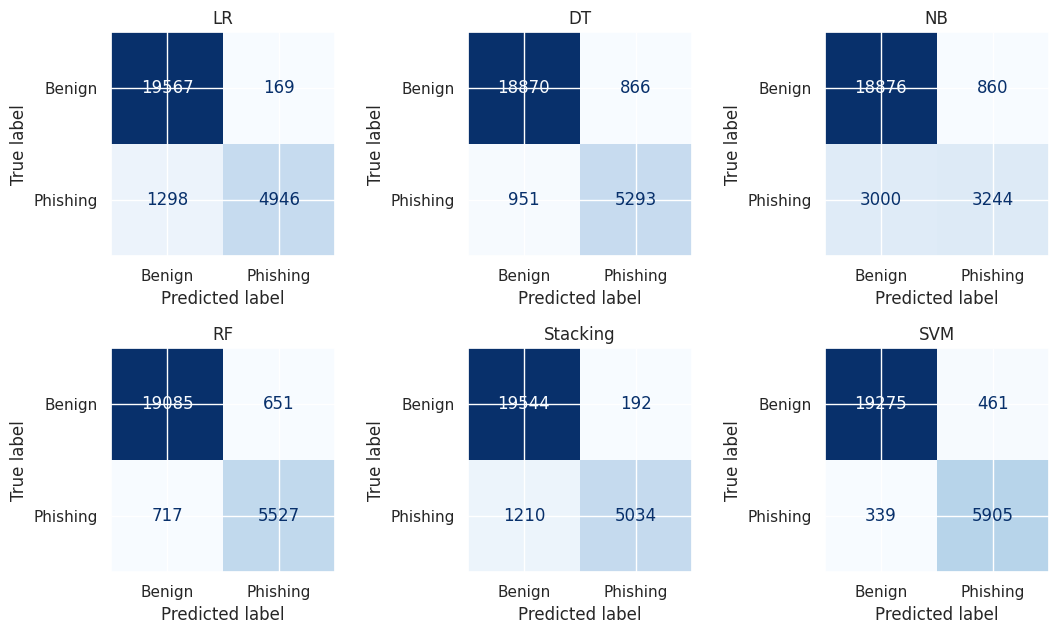

,model,acc,phish_prec,phish_rec,phish_f1,bal_acc,mcc,roc_auc,pr_auc,TP,TN,FP,FN,selected_on_train_cv
0,LR,0.9435,0.9670,0.7921,0.8709,0.8918,0.8420,0.9882,0.9650,4946,19567,169,1298,False
1,DT,0.9301,0.8594,0.8477,0.8535,0.9019,0.8076,0.9792,0.9329,5293,18870,866,951,False
2,NB,0.8514,0.7904,0.5195,0.6270,0.7380,0.5576,0.9336,0.7861,3244,18876,860,3000,False
3,RF,0.9473,0.8946,0.8852,0.8899,0.9261,0.8553,0.9875,0.9665,5527,19085,651,717,False
4,Stacking,0.9460,0.9633,0.8062,0.8778,0.8982,0.8490,0.9891,0.9712,5034,19544,192,1210,True
5,SVM,0.9692,0.9276,0.9457,0.9366,0.9612,0.9163,0.9926,0.9768,5905,19275,461,339,False


In [43]:
final, preds = [], {}
for m in MODELS:
    pipe, pred, sc, mt = fit_eval(m, tr, te, ALL_NUM, CAT_COLS, True, Xx, yx)
    mt["selected_on_train_cv"] = (m == selected); preds[m] = pred
    mt["ci95"] = json.dumps(cluster_bootstrap(yx.iloc[te], pred, Xx.iloc[te]["grp"]))
    final.append({"model": m, **mt})
E6 = pd.DataFrame(final); E6.to_csv(f"{OUT}/E6_final_test_metrics.csv", index=False)
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5))
for ax, m in zip(axes.ravel(), MODELS):
    ConfusionMatrixDisplay(confusion_matrix(yx.iloc[te], preds[m]), display_labels=["Benign", "Phishing"]).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(m)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_confusion_matrices.png", dpi=200); plt.show()
E6[["model", "acc", "phish_prec", "phish_rec", "phish_f1", "bal_acc", "mcc", "roc_auc", "pr_auc", "TP", "TN", "FP", "FN", "selected_on_train_cv"]].round(4)

In [44]:
# 95% domain-bootstrap CIs (resampling whole domains)
E6[["model", "ci95"]]

,model,ci95
0,LR,"{""phish_rec"": [0.7102, 0.8902], ""phish_prec"": ..."
1,DT,"{""phish_rec"": [0.7557, 0.9574], ""phish_prec"": ..."
2,NB,"{""phish_rec"": [0.2541, 0.8411], ""phish_prec"": ..."
3,RF,"{""phish_rec"": [0.8019, 0.9845], ""phish_prec"": ..."
4,Stacking,"{""phish_rec"": [0.6964, 0.9385], ""phish_prec"": ..."
5,SVM,"{""phish_rec"": [0.935, 0.9652], ""phish_prec"": [..."


In [45]:
# landing-page confound diagnostic (R7.4): test performance by path-length bucket
te_df = Xx.iloc[te].assign(y=yx.iloc[te].values)
bucket = pd.cut(te_df.path_len, [-1, 0, 5, 15, 1e9], labels=["0", "1-5", "6-15", ">15"])
diag = []
for m in MODELS:
    te_df["pred"] = preds[m]
    for b, g in te_df.groupby(bucket, observed=True):
        diag.append({"model": m, "path_len_bucket": b, "n": len(g), "phish_share": g.y.mean(), "accuracy": (g.y == g.pred).mean(),
                     "benign_FPR": ((g.pred == 1) & (g.y == 0)).sum()/max((g.y == 0).sum(), 1),
                     "phish_recall": ((g.pred == 1) & (g.y == 1)).sum()/max((g.y == 1).sum(), 1)})
E6b = pd.DataFrame(diag); E6b.to_csv(f"{OUT}/E6_pathlen_bucket_diagnostic.csv", index=False)
E6b[E6b.model == selected].round(4)

,model,path_len_bucket,n,phish_share,accuracy,benign_FPR,phish_recall
16,Stacking,0,2488,0.1113,0.9767,0.0068,0.8448
17,Stacking,1-5,17122,0.1730,0.9376,0.0045,0.6610
18,Stacking,6-15,2488,0.3099,0.9602,0.0303,0.9390
19,Stacking,>15,3882,0.5755,0.9544,0.0370,0.9481


In [46]:
# LaTeX table for the paper (phishing-class metrics, %)
show = E6[["model", "acc", "phish_prec", "phish_rec", "phish_f1", "bal_acc", "mcc"]].copy()
for c in show.columns[1:]: show[c] = show[c] * (100 if c != "mcc" else 1)
tex = show.set_index("model").to_latex(float_format=lambda v: "%.2f" % v, caption="Phishing-class metrics on the domain-held-out test set.", label="tab:phish_class")
open(f"{OUT}/table_phishing_class.tex", "w").write(tex); print(tex)

\begin{table}
\caption{Phishing-class metrics on the domain-held-out test set.}
\label{tab:phish_class}
\begin{tabular}{lrrrrrr}
\toprule
 & acc & phish_prec & phish_rec & phish_f1 & bal_acc & mcc \\
model &  &  &  &  &  &  \\
\midrule
LR & 94.35 & 96.70 & 79.21 & 87.09 & 89.18 & 0.84 \\
DT & 93.01 & 85.94 & 84.77 & 85.35 & 90.19 & 0.81 \\
NB & 85.14 & 79.04 & 51.95 & 62.70 & 73.80 & 0.56 \\
RF & 94.73 & 89.46 & 88.52 & 88.99 & 92.61 & 0.86 \\
Stacking & 94.60 & 96.33 & 80.62 & 87.78 & 89.82 & 0.85 \\
SVM & 96.92 & 92.76 & 94.57 & 93.66 & 96.12 & 0.92 \\
\bottomrule
\end{tabular}
\end{table}



## E3. Repeated grouped splits — mean ± std and paired Wilcoxon (R3, statistical analysis)

In [47]:
rep = []
for s in range(REPEATS):
    tr_, te_ = group_split(Xx, yx, s)
    for m in MODELS:
        _, _, _, mt = fit_eval(m, tr_, te_, ALL_NUM, CAT_COLS, True, Xx, yx, seed=s)
        rep.append({"seed": s, "model": m, **mt}); print("E3 seed", s, m, round(mt["phish_f1"], 4))
E3 = pd.DataFrame(rep); E3.to_csv(f"{OUT}/E3_repeated_splits_raw.csv", index=False)
cols = ["acc", "phish_prec", "phish_rec", "phish_f1", "bal_acc", "mcc", "pr_auc"]
E3_summary = E3.groupby("model")[cols].agg(["mean", "std"]); E3_summary.to_csv(f"{OUT}/E3_repeated_splits_summary.csv")
best = E3.groupby("model")["phish_f1"].mean().idxmax(); wil = []
for m in MODELS:
    if m != best and REPEATS >= 5:
        x1 = E3[E3.model == best].sort_values("seed").phish_f1.values; x2 = E3[E3.model == m].sort_values("seed").phish_f1.values
        wil.append({"best": best, "other": m, "wilcoxon_p": wilcoxon(x1, x2).pvalue if np.any(x1 != x2) else 1.0})
pd.DataFrame(wil).to_csv(f"{OUT}/E3_wilcoxon_vs_best.csv", index=False)
print("best by mean phishing-F1:", best)
E3_summary.round(4)

E3 seed 0 LR 0.8671
E3 seed 0 DT 0.8874
E3 seed 0 NB 0.5662
E3 seed 0 RF 0.8678
E3 seed 0 Stacking 0.8498
E3 seed 0 SVM 0.9334
E3 seed 1 LR 0.875
E3 seed 1 DT 0.8468
E3 seed 1 NB 0.693
E3 seed 1 RF 0.8851
E3 seed 1 Stacking 0.9223
E3 seed 1 SVM 0.9158
E3 seed 2 LR 0.9099
E3 seed 2 DT 0.8819
E3 seed 2 NB 0.8041
E3 seed 2 RF 0.9126
E3 seed 2 Stacking 0.9293
E3 seed 2 SVM 0.931
E3 seed 3 LR 0.8632
E3 seed 3 DT 0.7426
E3 seed 3 NB 0.5439
E3 seed 3 RF 0.8628
E3 seed 3 Stacking 0.8559
E3 seed 3 SVM 0.922
E3 seed 4 LR 0.7994
E3 seed 4 DT 0.6969
E3 seed 4 NB 0.486
E3 seed 4 RF 0.8009
E3 seed 4 Stacking 0.866
E3 seed 4 SVM 0.853
best by mean phishing-F1: SVM


acc         phish_prec         phish_rec         phish_f1  \
            mean     std       mean     std      mean     std     mean   
model                                                                    
DT        0.9395  0.0203     0.7624  0.1133    0.8863  0.1202   0.8111   
LR        0.9602  0.0118     0.9198  0.0381    0.8136  0.0521   0.8629   
NB        0.8932  0.0401     0.6961  0.1188    0.5710  0.1648   0.6186   
RF        0.9572  0.0116     0.8349  0.0700    0.9047  0.0596   0.8658   
SVM       0.9724  0.0034     0.8723  0.0524    0.9546  0.0172   0.9110   
Stacking  0.9640  0.0189     0.9304  0.0322    0.8461  0.0687   0.8846   

                 bal_acc             mcc          pr_auc          
             std    mean     std    mean     std    mean     std  
model                                                             
DT        0.0864  0.9191  0.0573  0.7835  0.0871  0.9000  0.0533  
LR        0.0400  0.9007  0.0255  0.8418  0.0382  0.9467  0.0302  
NB        0.1283  0.7640  0.0816  0.5672  0.1320  0.6644  0.1073  
RF        0.0412  0.9368  0.0285  0.8425  0.0406  0.9528  0.0267  
SVM       0.0332  0.9651  0.0080  0.8959  0.0301  0.9672  0.0209  
Stacking  0.0381  0.9176  0.0345  0.8657  0.0443  0.9594  0.0241

In [48]:
pd.DataFrame(wil)   # note: with only 5 seeds the minimum possible two-sided Wilcoxon p is 0.0625; use REPEATS>=10 for a meaningful test

,best,other,wilcoxon_p
0,SVM,LR,0.0625
1,SVM,DT,0.0625
2,SVM,NB,0.0625
3,SVM,RF,0.0625
4,SVM,Stacking,0.6250


## E5. K-Means with effect size (R7.6)

In [49]:
Zc = StandardScaler().fit_transform(dfx[ALL_NUM])
km2 = KMeans(2, random_state=SEED, n_init=10).fit(Zc); lab = km2.labels_
tab = pd.crosstab(lab, dfx.label); print(tab)
chi_nc, v_nc = cramers_v(tab, correction=False); chi_c, v_c = cramers_v(tab, correction=True)
km_out = {"chi2_yates(as in earlier cell)": chi_c, "cramers_v_yates": v_c, "chi2_no_correction": chi_nc, "cramers_v_no_correction": v_nc,
          "ARI": adjusted_rand_score(dfx.label, lab), "NMI": normalized_mutual_info_score(dfx.label, lab),
          "phishing_share_in_cluster": {int(k): float(v) for k, v in dfx.groupby(lab).label.mean().items()},
          "share_of_all_phishing_in_cluster": {int(k): float(v) for k, v in (tab[1]/tab[1].sum()).items()}}
json.dump(km_out, open(f"{OUT}/E5_kmeans.json", "w"), indent=2); print(json.dumps(km_out, indent=1))

label      0      1
row_0              
0        309   1939
1      98332  14651
{
 "chi2_yates(as in earlier cell)": 9599.751879058238,
 "cramers_v_yates": 0.2886325715324727,
 "chi2_no_correction": 9605.697464146186,
 "cramers_v_no_correction": 0.2887219396694312,
 "ARI": 0.15022177193262923,
 "NMI": 0.10254095173817046,
 "phishing_share_in_cluster": {
  "0": 0.8625444839857651,
  "1": 0.1296743757910482
 },
 "share_of_all_phishing_in_cluster": {
  "0": 0.11687763713080168,
  "1": 0.8831223628691983
 }
}


In [50]:
import category_encoders as ce; print(ce.__version__)
Z = target_enc_cv.fit_transform(X_train[['dom','tld']], y_train)   # training encoded values
print(pd.DataFrame(Z).corrwith(y_train.reset_index(drop=True)))     # ~0 hole misaligned

2.11.1
dom   -0.057667
tld   -0.075132
dtype: float64


In [51]:
import numpy as np, pandas as pd
Z = np.asarray(target_enc_cv.fit_transform(X_train[['dom','tld']], y_train))
print(pd.DataFrame(Z, columns=['dom','tld']).corrwith(pd.Series(y_train.to_numpy())).round(3))

dom    0.739
tld    0.703
dtype: float64


In [52]:
from category_encoders.wrapper import NestedCVWrapper
cols = ['dom','tld'] + ALL_NUM
Xa, Xb = Xx.iloc[tr][cols], Xx.iloc[te][cols]

def lr_with(enc):
    p = Pipeline([('prep', ColumnTransformer([('te', enc, ['dom','tld']), ('sc', StandardScaler(), ALL_NUM)])),
                  ('model', LogisticRegression(max_iter=1000, random_state=42))])
    p.fit(Xa, yx.iloc[tr]); pr = p.predict(Xb)
    return round((pr == yx.iloc[te]).mean(), 4), round(recall_score(yx.iloc[te], pr), 4)

print("ce wrapper :", lr_with(NestedCVWrapper(ce.TargetEncoder(smoothing=10), cv=5, random_state=42)))
Xa2 = Xx.iloc[tr][cols + ['grp']]; Xb2 = Xx.iloc[te][cols + ['grp']]
p = build_pipe("LR", ALL_NUM, ["dom","tld"], grouped_te=False)
p.fit(Xa2, yx.iloc[tr]); pr = p.predict(Xb2)
print("my encoder :", round((pr == yx.iloc[te]).mean(), 4), round(recall_score(yx.iloc[te], pr), 4))

ce wrapper : (np.float64(0.8926), 0.5621)
my encoder : 0.8926 0.5621


In [ ]:
import pandas as pd
D = "/kaggle/working/phishing_results"
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 50)
print(pd.read_csv(D + "/E4_train_cv_selection.csv").round(4).to_string())
raw = pd.read_csv(D + "/E3_repeated_splits_raw.csv")
cols = ["acc", "phish_prec", "phish_rec", "phish_f1", "bal_acc"]
print(raw.groupby("model")[cols].agg(["mean", "std"]).round(4).to_string())
print(pd.read_csv(D + "/E3_wilcoxon_vs_best.csv").round(4).to_string())
print(pd.read_csv(D + "/E6_final_test_metrics.csv")[["model", "roc_auc", "pr_auc", "ci95"]].to_string())